THIS NOTEBOOK IS HEAVILY BASED ON THE ONE FROM THE LECTURE

In [1]:
import sys

# to import stuff from task 1
sys.path.insert(0, "../01-dollar-recognizer")

from matplotlib import pyplot as plt
import numpy as np
import os
import random

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, LSTM

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# resample signal to n samples
from scipy.signal import resample

# XML parser
import xml.etree.ElementTree as ET

# encoding and normalizing data
from sklearn.preprocessing import LabelEncoder, StandardScaler

Changed to match the $ recognizer

In [2]:
NUM_POINTS = 64

## Read Data

In [3]:
data = []

for root, subdirs, files in os.walk('../datasets/logs'):
    if 'ipynb_checkpoint' in root:
        continue
    
    if len(files) > 0:
        for f in tqdm(files):
            if '.xml' in f:
                fname = f.split('.')[0]
                label = fname[:-2]

                # not in DollarRecognizer -> ignore
                if label == "question_mark":
                    continue
                
                xml_root = ET.parse(f'{root}/{f}').getroot()
                
                points = []
                for element in xml_root.findall('Point'):
                    x = element.get('X')
                    y = element.get('Y')
                    points.append([x, y])
                    
                points = np.array(points, dtype=float)
                
                scaler = StandardScaler()
                points = scaler.fit_transform(points)
                
                resampled = resample(points, NUM_POINTS)
                
                data.append((label, resampled))

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

...

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

In [4]:
print(data[0])

('arrow', array([[-1.98115675,  1.98053787],
       [-2.20043433,  2.06559137],
       [-1.86038347,  1.85996647],
       [-1.9991058 ,  1.83974742],
       [-1.86375486,  1.75365047],
       [-1.77989447,  1.7142282 ],
       [-1.79132784,  1.64509496],
       [-1.59691856,  1.47681285],
       [-1.59960063,  1.43600812],
       [-1.57421207,  1.39125664],
       [-1.38295703,  1.23016538],
       [-1.27212639,  1.06805942],
       [-1.10064264,  0.93685586],
       [-0.93467668,  0.80936053],
       [-0.79769288,  0.63300337],
       [-0.59052491,  0.49206682],
       [-0.42558182,  0.39232612],
       [-0.25563408,  0.22000616],
       [-0.06836792,  0.09015649],
       [ 0.10115762, -0.01209009],
       [ 0.249479  , -0.15220363],
       [ 0.31353968, -0.19229567],
       [ 0.41974264, -0.24608916],
       [ 0.54602622, -0.37173521],
       [ 0.60168464, -0.4244685 ],
       [ 0.71118572, -0.48664805],
       [ 0.78867563, -0.55307626],
       [ 0.82536278, -0.56401036],
       [ 0

In [5]:
test_data = []

for root, subdirs, files in os.walk('../datasets/mylogs'):
    if 'ipynb_checkpoint' in root:
        continue
    
    if len(files) > 0:
        for f in tqdm(files):
            if '.xml' in f:
                fname = f.split('.')[0]
                label = fname[:-2]
                
                xml_root = ET.parse(f'{root}/{f}').getroot()
                
                points = []
                for element in xml_root.findall('Point'):
                    x = element.get('X')
                    y = element.get('Y')
                    points.append([x, y])
                    
                points = np.array(points, dtype=float)
                
                scaler = StandardScaler()
                points = scaler.fit_transform(points)
                
                resampled = resample(points, NUM_POINTS)
                
                test_data.append((label, resampled))

  0%|          | 0/150 [00:00<?, ?it/s]

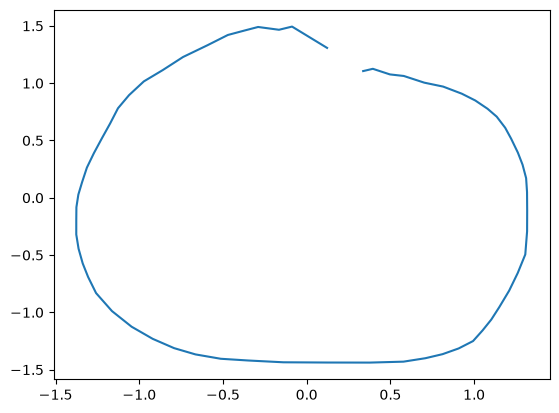

In [6]:
sample = random.sample(test_data, 1)[0]
label = sample[0]
sequence = sample[1]
plt.plot(sequence.T[0], sequence.T[1] * -1)

## Prepare Data

In [7]:
# Prepare the data
labels = [sample[0] for sample in data]
print("labels: ", set(labels))

# encode (make string-labels numerical)
encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)
print("encoded: ", set(labels_encoded))

# get labels of data
y = to_categorical(labels_encoded)
print("num labels (encoded): ", len(y[0]))

# get point sequences of data
sequences = [sample[1] for sample in data]
X = np.array(sequences)

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

labels:  {'delete_mark', 'rectangle', 'left_curly_brace', 'check', 'right_curly_brace', 'star', 'circle', 'triangle', 'caret', 'v', 'arrow', 'left_sq_bracket', 'x', 'right_sq_bracket', 'pigtail'}
encoded:  {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)}
num labels (encoded):  15
(3960, 64, 2) (990, 64, 2) (3960, 15) (990, 15)


## Define and Train Models

In [8]:
# models
models = {}

# values to compare
lstm_values = [8, 16, 32, 64, 128]

# callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=3)

In [9]:
# create models for every value
for lstm_value in lstm_values:

    model = Sequential()
    
    model.add(Input((NUM_POINTS, 2)))
    model.add(LSTM(lstm_value))

    model.add(Dense(32, activation='relu'))

    model.add(Dense(len(set(labels)), activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    models[lstm_value] = model

    

In [10]:
# train models and save history for every model

histories = {}

for lstm_value, model in models.items():
    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1,
        callbacks=[reduce_lr, stop_early]
    )
    histories[lstm_value] = history

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1876 - loss: 2.3903 - val_accuracy: 0.1848 - val_loss: 1.9571 - learning_rate: 0.0010
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5008 - loss: 1.6083 - val_accuracy: 0.6333 - val_loss: 1.2699 - learning_rate: 0.0010
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7159 - loss: 0.9937 - val_accuracy: 0.7646 - val_loss: 0.7661 - learning_rate: 0.0010
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8149 - loss: 0.6295 - val_accuracy: 0.8444 - val_loss: 0.5322 - learning_rate: 0.0010
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8674 - loss: 0.4540 - val_accuracy: 0.8808 - val_loss: 0.4041 - learning_rate: 0.0010
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9071 - loss: 0.3541 - val_accuracy: 0.9273 - val_loss: 0.3323 - learning_rate: 0.0010
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9265 - loss: 0.2913 - 

In [11]:
# summary for every model
for lstm_value, model in models.items():
    print('--------------------------------------------------------------')
    print(f'Model with {lstm_value} LSTM units:')
    print('--------------------------------------------------------------')
    model.summary()

--------------------------------------------------------------
Model with 8 LSTM units:
--------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,407 (13.31 KB)

 Trainable params: 1,135 (4.43 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 128)            │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,087 (840.19 KB)

 Trainable params: 71,695 (280.06 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 143,392 (560.13 KB)

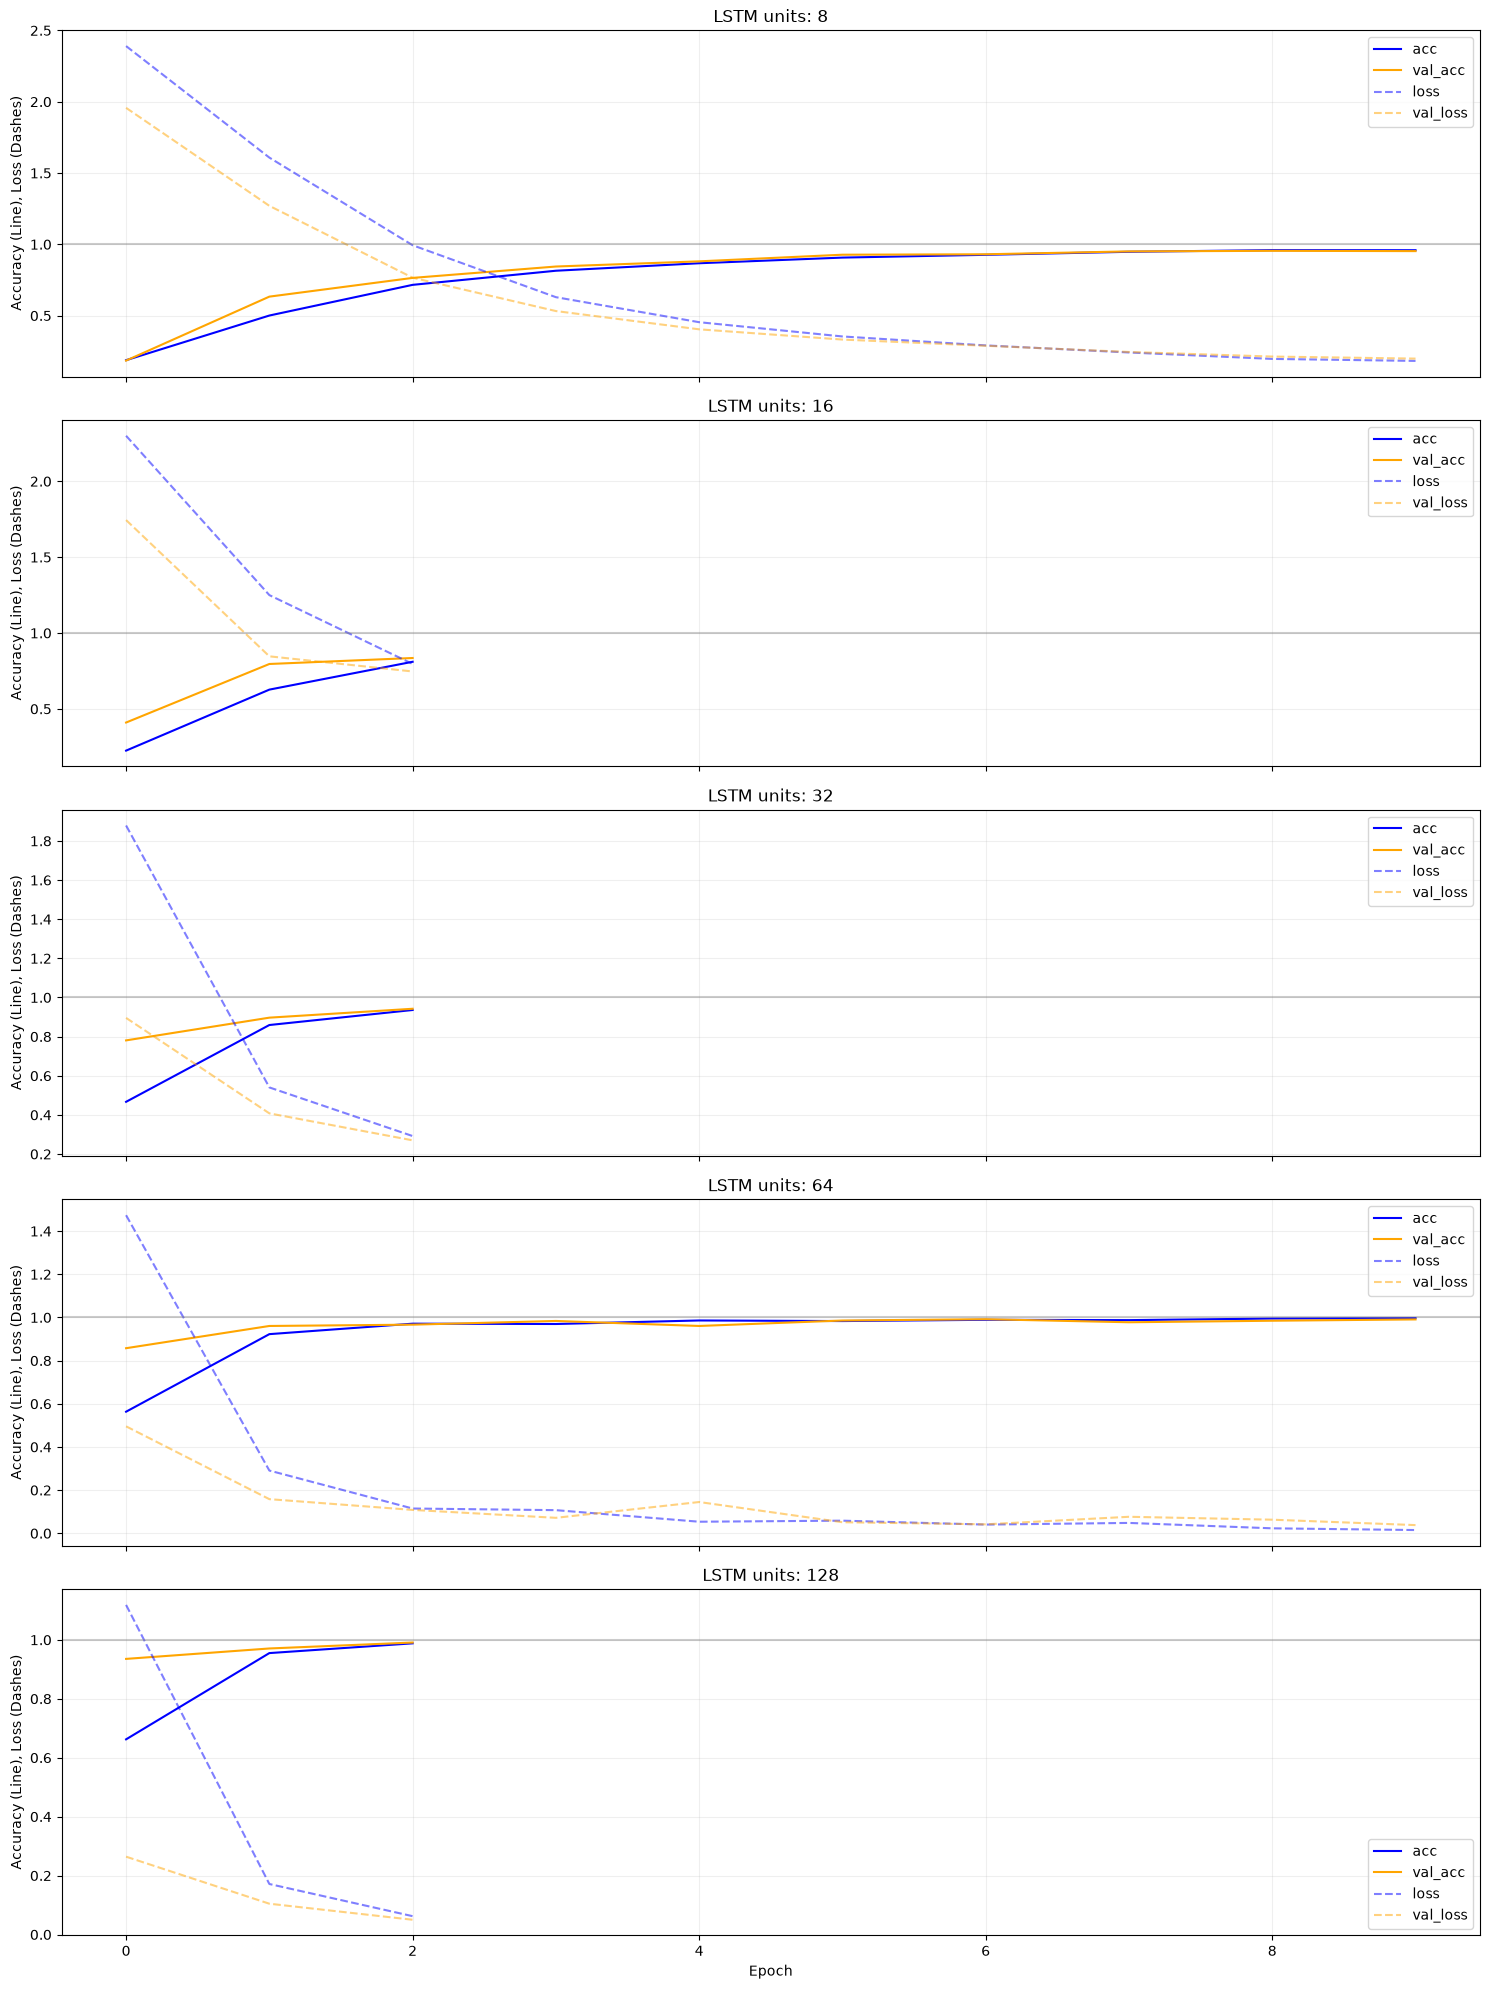

In [12]:
items = histories.items()
n = len(items)

fig, axes = plt.subplots(n, 1, figsize=(15, 4 * n), sharex=True)

for ax, (lstm_value, hist) in zip(axes, items):
    loss = hist.history["loss"]
    val_loss = hist.history["val_loss"]
    accuracy = hist.history["accuracy"]
    val_accuracy = hist.history["val_accuracy"]

    ax.plot(accuracy, color="blue", label="acc")
    ax.plot(val_accuracy, color="orange", label="val_acc")
    ax.plot(loss, "--", color="blue", alpha=0.5, label="loss")
    ax.plot(val_loss, "--", color="orange", alpha=0.5, label="val_loss")

    ax.set_title(f"LSTM units: {lstm_value}")
    ax.set_ylabel("Accuracy (Line), Loss (Dashes)")
    ax.axhline(1, color="gray", alpha=0.4)
    ax.grid(alpha=0.2)
    ax.legend(loc="best")

axes[-1].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

rows = []
for lstm_value, hist in sorted(histories.items()):
    h = hist.history
    rows.append({
        "lstm_units": lstm_value,
        "final_train_acc": h["accuracy"][-1],
        "final_val_acc": h["val_accuracy"][-1],
        "final_train_loss": h["loss"][-1],
        "final_val_loss": h["val_loss"][-1],
        "best_val_acc": max(h["val_accuracy"]),
        "best_val_loss": min(h["val_loss"]),
        "epochs_ran": len(h["loss"]),
    })

results_df = pd.DataFrame(rows).sort_values("lstm_units").reset_index(drop=True)

results_df

,lstm_units,final_train_acc,final_val_acc,final_train_loss,final_val_loss,best_val_acc,best_val_loss,epochs_ran
0,8,0.958838,0.952525,0.182586,0.198745,0.954545,0.198745,10
1,16,0.810606,0.835354,0.796113,0.746645,0.835354,0.746645,3
2,32,0.936111,0.942424,0.291972,0.270087,0.942424,0.270087,3
3,64,0.996970,0.990909,0.015072,0.038000,0.991919,0.038000,10
4,128,0.988131,0.990909,0.062302,0.050152,0.990909,0.050152,3


The accuracies get better the higher our parameter is. However the parameter 64 performs a bit better than 128, so it seems like 64 is the better choice.<br>
The losses seem to behave in quite a similar way. They get smaller the higher our value is. The losses at 128 are higher than the ones on 64 though, so it seems like overfitting.<br>
The number of Epochs was always at 3 except for the parameters 8 and 64 -> 8 probably took long to find any plateu and 64 probably found a better plateau. However 128 is pretty close to 64.<br><br>
To better evaluate them though we should look at confusion matrixes.


## Predict

In [14]:
predictions = {}

for lstm_value, model in models.items():
    predictions[lstm_value] = model.predict(X_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [15]:
cms = {}
accuracies = {}

for lstm_value, preds in predictions.items():
    
    correct = 0
    incorrect = 0

    for pred, true in zip(preds, y_test):
        pred_label_encoded = np.argmax(pred)
        pred_label = encoder.inverse_transform(np.array([pred_label_encoded]))[0]

        true_label_encoded = np.argmax(true)
        true_label = encoder.inverse_transform(np.array([true_label_encoded]))[0]

        if pred_label == true_label:
            correct += 1
        else:
            incorrect += 1

    accuracy = correct / (correct + incorrect)
    accuracies[lstm_value] = accuracy

    cm = confusion_matrix(
        y_true=[encoder.inverse_transform([np.argmax(true)])[0] for true in y_test],
        y_pred=[encoder.inverse_transform([np.argmax(pred)])[0] for pred in preds]
    )

    cms[lstm_value] = cm

In [16]:
for lstm_value, accuracy in accuracies.items():
    print(f'LSTM units: {lstm_value}, Accuracy: {accuracy:.4f}')

LSTM units: 8, Accuracy: 0.9525
LSTM units: 16, Accuracy: 0.8354
LSTM units: 32, Accuracy: 0.9424
LSTM units: 64, Accuracy: 0.9909
LSTM units: 128, Accuracy: 0.9909


The accuracy was increasing as the lstm value increased. But 128 is slightly worse than 64. This doesn't really suggest overfitting cause they are so similar.

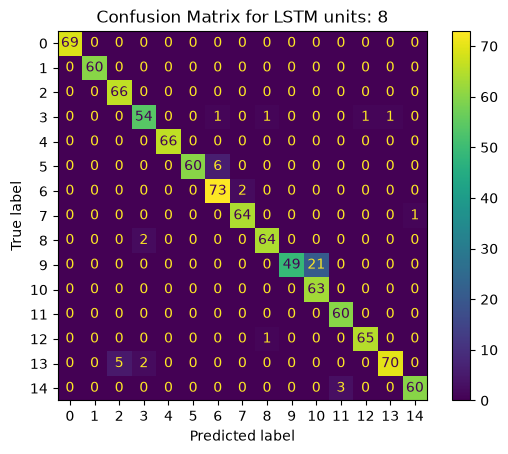

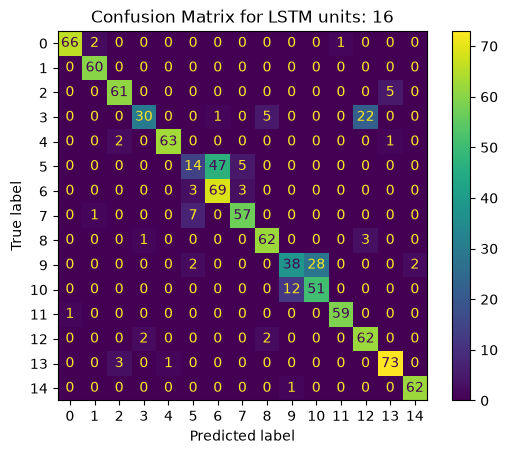

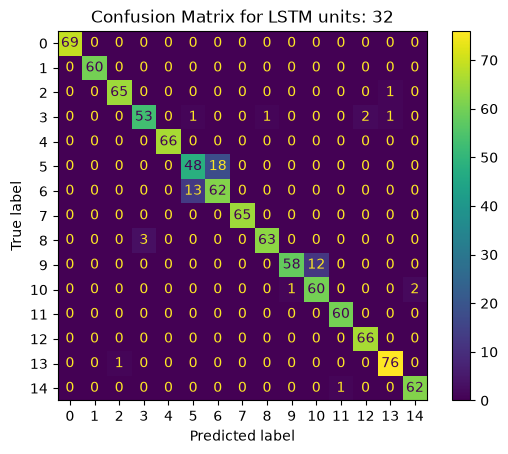

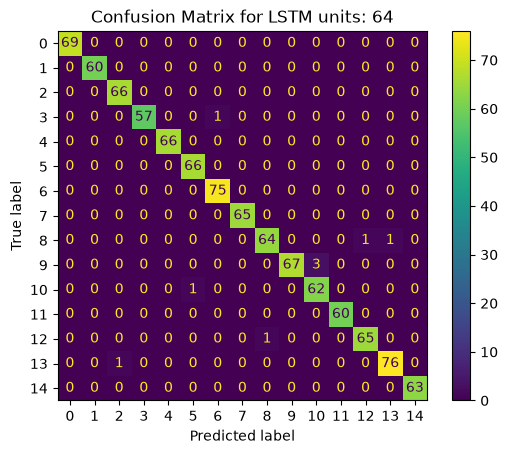

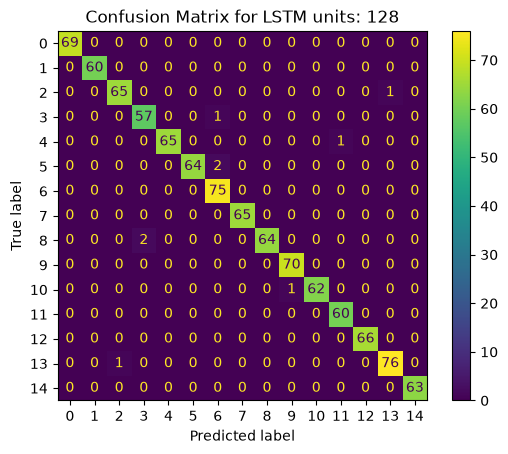

In [17]:
for lstm_value, cm in cms.items():
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix for LSTM units: {lstm_value}')
    plt.show()

The confusion Matrices show what the accuracies implied. 64 is a sweet spot for this use case and 128 overfits.

## Comparison with DollarRecognizer

In [18]:
from recognizer import DollarRecognizer

recognizer = DollarRecognizer()

In [19]:
test_labels_dollar = []
test_sequences_dollar_raw = []

for root, subdirs, files in os.walk("../datasets/mylogs"):
    if "ipynb_checkpoint" in root:
        continue

    # go through all files in dataset
    for f in files:
        if ".xml" not in f:
            continue

        # get label from filename
        fname = f.split(".")[0]
        label = fname[:-2]

        # delete_mark -> delete
        if label == "delete_mark":
            label_normalized = "delete"
        else:
            label_normalized = label

        # parse XML and get points
        xml_root = ET.parse(f"{root}/{f}").getroot()
        points = []

        # get points from XML
        for element in xml_root.findall("Point"):
            x = float(element.get("X"))
            y = float(element.get("Y"))
            points.append([x, y])

        # get data in right format for recognizer
        test_labels_dollar.append(label_normalized)
        test_sequences_dollar_raw.append(points)

In [20]:
from recognizer_helper import Point

dollar_predictions = []
dollar_correct = 0
dollar_incorrect = 0

for i, sequence in enumerate(test_sequences_dollar_raw):
    candidate = [Point(x, y) for x, y in sequence]
    result = recognizer.recognize(candidate)
    dollar_predictions.append(result.name)

    if result.name == test_labels_dollar[i]:
        dollar_correct += 1
    else:
        dollar_incorrect += 1

dollar_accuracy = dollar_correct / (dollar_correct + dollar_incorrect)
print("Dollar accuracy:", round(dollar_accuracy, 4))

Dollar accuracy: 0.7133


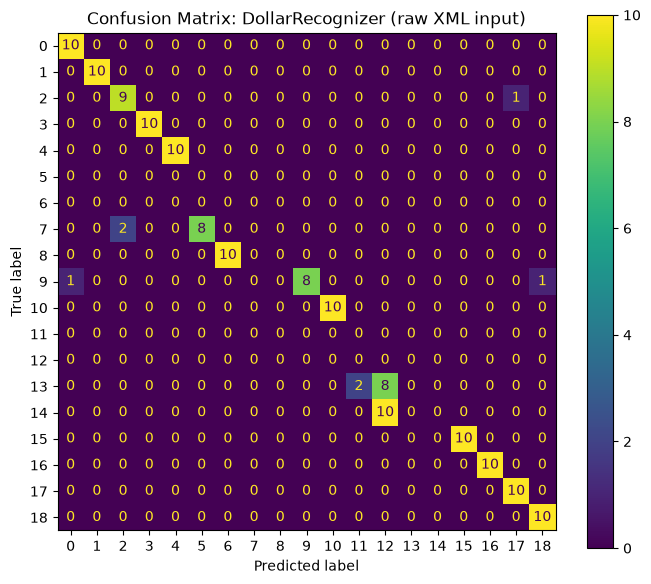

In [21]:
cm_dollar = confusion_matrix(
    y_true=test_labels_dollar,
    y_pred=dollar_predictions,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dollar,
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax)
ax.set_title("Confusion Matrix: DollarRecognizer (raw XML input)")
plt.tight_layout()
plt.show()

The accuracy overall is worse than in every model here. This is also pretty obvious in the confusion matrix.

## Saving the best model

In [22]:
# save the best model
best_lstm_value = max(accuracies, key=accuracies.get)
best_model = models[best_lstm_value]
best_model.save(f"../model/model_lstm_{best_lstm_value}.keras")